# AI-Generated Face Detection with EfficientNetV2S
## Final Local Training Notebook for RTX 3060 · Source-Test Revision

이 노트북은 **EfficientNetV2S 단일 모델**로 실제 얼굴 이미지와 AI 생성 얼굴 이미지를 분류하기 위한 최종 학습 코드입니다.

### 목표
- 5만~10만 장 이상의 로컬 이미지 학습
- 동일 분포 통합 테스트(ID Test)와 생성 소스별 테스트(Source Test) 비교
- 학습에 포함하지 않은 생성 소스는 OOD로 명시하여 일반화 성능 분석
- Accuracy뿐 아니라 Fake 클래스 기준 Precision / Recall / F1, Macro F1, ROC-AUC 분석
- Grad-CAM으로 모델 판단 영역 확인
- 최종 `.keras` 모델 및 Streamlit 시연 코드 저장

### 데이터 폴더 구조

```text
data/
├── train/
│   ├── fake/
│   └── real/
├── valid/
│   ├── fake/
│   └── real/
├── test/                              # ID Test: 통합 독립 테스트셋
│   ├── fake/
│   └── real/
└── test_by_source/                    # 소스별 성능 평가셋
    ├── gravex/
    │   ├── fake/
    │   └── real/
    ├── stylegan/
    │   ├── fake/
    │   └── real/
    └── flux_sdxl/
        ├── fake/
        └── real/
```

### 중요한 데이터 원칙
- `fake=0`, `real=1`로 고정합니다.
- `test_by_source`의 모든 폴더가 자동으로 OOD인 것은 아닙니다.
- **학습에 넣지 않은 생성 소스만** 설정 셀의 `OOD_SOURCE_NAMES`에 기록합니다.
- 각 source test의 `real`도 train/valid/test와 겹치지 않는 독립 이미지여야 합니다.
- 동일 인물, 동일 파일, 원본/리사이즈 복사본이 서로 다른 split에 섞이면 데이터 누수가 발생할 수 있습니다.

### EfficientNetV2S 전처리 주의
EfficientNetV2S는 기본적으로 모델 내부에 입력 전처리가 포함되어 있습니다.  
따라서 이 노트북에서는 이미지 픽셀을 `/255.`로 나누지 않고 **0~255 범위 그대로** 모델에 입력합니다.


## 0. 실행 전 환경 확인

In [4]:
# 처음 환경 구축 시 필요 패키지 예시:
# pip install tensorflow pandas numpy matplotlib scikit-learn pillow streamlit
#
# Windows에서 GPU TensorFlow 환경은 설치 방식에 따라 다를 수 있습니다.
# 아래 셀에서 GPU가 감지되지 않으면 학습 전에 TensorFlow GPU 설정부터 확인하세요.

from pathlib import Path
import os
import json
import random
import hashlib
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image as PILImage
import tensorflow as tf
from tensorflow.keras import layers, mixed_precision
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as error:
            print("GPU memory growth 설정 경고:", error)
    mixed_precision.set_global_policy("mixed_float16")
    print("GPU detected:", gpus)
    print("Mixed precision policy:", mixed_precision.global_policy())
else:
    mixed_precision.set_global_policy("float32")
    print("WARNING: GPU가 감지되지 않았습니다.")
    print("현재 policy:", mixed_precision.global_policy())

TensorFlow version: 2.21.0
GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


## 1. 프로젝트 설정: 이 셀만 먼저 수정하세요

데이터 경로와 실험 기본 설정을 이 셀에서 확정합니다.

In [10]:
# ==========================================================
# 필수 수정: 본인 컴퓨터의 data 폴더 위치로 변경
# ==========================================================
DATA_DIR = Path("/home/hyojin/ai_image_detection/data")

# 실험명을 변경하면 결과가 새 폴더에 저장됩니다.
# 데이터 구성이나 학습 조건을 바꿔 다시 돌릴 때마다 이름을 바꾸세요.
RUN_NAME = "efficientnetv2s_experiment_01"

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

# ==========================================================
# Source별 Test 폴더
# prepare_dataset.py도 아래 경로를 생성하도록 통일하세요.
# 각 폴더 내부에는 fake/ real/ 폴더가 있어야 합니다.
# ==========================================================
SOURCE_TEST_DIRS = {
    "gravex": DATA_DIR / "test_by_source" / "gravex",
    "stylegan": DATA_DIR / "test_by_source" / "stylegan",
    "flux_sdxl": DATA_DIR / "test_by_source" / "flux_sdxl",
}

# ==========================================================
# 중요: Train에 포함하지 않은 생성 source만 작성하세요.
# 예: train에 GRAVEX/StyleGAN이 포함되고 FLUX·SDXL이 포함되지 않았다면 아래 그대로 사용
# train 구성에 따라 반드시 직접 수정해야 합니다.
# ==========================================================
OOD_SOURCE_NAMES = set()

OUTPUT_ROOT = Path("./outputs") / RUN_NAME
MODEL_DIR = OUTPUT_ROOT / "models"
RESULT_DIR = OUTPUT_ROOT / "results"
GRADCAM_DIR = OUTPUT_ROOT / "gradcam"
APP_DIR = OUTPUT_ROOT / "app"
BACKUP_DIR = OUTPUT_ROOT / "training_backup"

for folder in [MODEL_DIR, RESULT_DIR, GRADCAM_DIR, APP_DIR, BACKUP_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# ==========================================================
# RTX 3060 권장 시작 설정
# ==========================================================
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16                  # 안정 확인 후 32 시도 가능
HEAD_EPOCHS = 5                  # 첫 실행 테스트라면 3으로 낮춰도 됨
FINETUNE_EPOCHS = 5

RUN_HEAD_TRAINING = True
RUN_FINE_TUNING = False          # Head 결과 확인 후 True로 변경

LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE = 1e-5
UNFREEZE_LAST_N = 60             # Fine-tuning 시 EfficientNetV2S 마지막 일부만 학습

# 검증 데이터에서 Macro F1가 최대가 되는 threshold를 선정한 뒤
# ID/Source Test 모두 동일 threshold를 적용합니다.
OPTIMIZE_THRESHOLD_ON_VALID = True

# 대규모 데이터 점검 기능: 처음 전체 데이터 구성 후 필요 시 True로 실행
RUN_CORRUPT_IMAGE_CHECK = False
RUN_EXACT_DUPLICATE_CHECK = False

CLASS_NAMES = ["fake", "real"]   # class index 고정: fake=0, real=1

HEAD_WEIGHTS_PATH = MODEL_DIR / "best_head.weights.h5"
FINE_WEIGHTS_PATH = MODEL_DIR / "best_finetuned.weights.h5"
FINAL_MODEL_PATH = MODEL_DIR / "efficientnetv2s_fake_face_final.keras"
INFERENCE_CONFIG_PATH = MODEL_DIR / "inference_config.json"

print("DATA_DIR:", DATA_DIR)
print("결과 저장 폴더:", OUTPUT_ROOT.resolve())
print("IMAGE_SIZE:", IMAGE_SIZE, "| BATCH_SIZE:", BATCH_SIZE)
print("Source test 경로:", SOURCE_TEST_DIRS)
print("OOD로 해석할 source:", sorted(OOD_SOURCE_NAMES))


DATA_DIR: /home/hyojin/ai_image_detection/data
결과 저장 폴더: /home/hyojin/ai_image_detection/outputs/efficientnetv2s_experiment_01
IMAGE_SIZE: (256, 256) | BATCH_SIZE: 16
Source test 경로: {'gravex': PosixPath('/home/hyojin/ai_image_detection/data/test_by_source/gravex'), 'stylegan': PosixPath('/home/hyojin/ai_image_detection/data/test_by_source/stylegan'), 'flux_sdxl': PosixPath('/home/hyojin/ai_image_detection/data/test_by_source/flux_sdxl')}
OOD로 해석할 source: []


## 2. 데이터 폴더 및 클래스 분포 확인

데이터 폴더 존재 여부와 fake/real 이미지 수를 안정적으로 확인합니다.

In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

def list_image_files(directory: Path):
    if not directory.exists():
        return []
    return sorted(
        file for file in directory.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )

def count_images_by_class(directory: Path):
    return {
        class_name: len(list_image_files(directory / class_name))
        for class_name in CLASS_NAMES
    }

print("DATA_DIR exists:", DATA_DIR.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("VALID_DIR exists:", VALID_DIR.exists())
print("TEST_DIR exists:", TEST_DIR.exists())
print()
for source_name, source_dir in SOURCE_TEST_DIRS.items():
    print(f"{source_name} exists:", source_dir.exists())

required_dirs = {
    "train": TRAIN_DIR,
    "valid": VALID_DIR,
    "test_id": TEST_DIR,
}

missing = [str(path) for path in required_dirs.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "다음 필수 폴더가 존재하지 않습니다. DATA_DIR 또는 폴더 구조를 확인하세요:\n"
        + "\n".join(missing)
    )

unknown_ood_sources = OOD_SOURCE_NAMES - set(SOURCE_TEST_DIRS.keys())
if unknown_ood_sources:
    raise ValueError(
        "OOD_SOURCE_NAMES에는 SOURCE_TEST_DIRS에 등록된 source만 입력하세요: "
        + str(sorted(unknown_ood_sources))
    )

rows = []
for split_name, split_dir in required_dirs.items():
    counts = count_images_by_class(split_dir)
    for class_name, count in counts.items():
        rows.append({
            "dataset": split_name,
            "evaluation_type": "id" if split_name == "test_id" else "training_split",
            "class": class_name,
            "images": count
        })

for source_name, source_dir in SOURCE_TEST_DIRS.items():
    counts = count_images_by_class(source_dir)
    evaluation_type = "ood" if source_name in OOD_SOURCE_NAMES else "source_seen_or_mixed"
    for class_name, count in counts.items():
        rows.append({
            "dataset": f"test_source_{source_name}",
            "evaluation_type": evaluation_type,
            "class": class_name,
            "images": count
        })

existence_df = pd.DataFrame([
    {"path_name": "DATA_DIR", "path": str(DATA_DIR), "exists": DATA_DIR.exists()},
    {"path_name": "TRAIN_DIR", "path": str(TRAIN_DIR), "exists": TRAIN_DIR.exists()},
    {"path_name": "VALID_DIR", "path": str(VALID_DIR), "exists": VALID_DIR.exists()},
    {"path_name": "TEST_DIR", "path": str(TEST_DIR), "exists": TEST_DIR.exists()},
] + [
    {"path_name": f"test_by_source/{source_name}", "path": str(source_dir), "exists": source_dir.exists()}
    for source_name, source_dir in SOURCE_TEST_DIRS.items()
])

display(existence_df)

distribution_df = pd.DataFrame(rows)
distribution_table = distribution_df.pivot(
    index=["dataset", "evaluation_type"], columns="class", values="images"
).fillna(0).astype(int)

display(distribution_table)
distribution_df.to_csv(RESULT_DIR / "dataset_distribution_long.csv", index=False)
distribution_table.to_csv(RESULT_DIR / "dataset_distribution.csv")

errors = []
for split_name, split_dir in required_dirs.items():
    counts = count_images_by_class(split_dir)
    if not split_dir.exists():
        errors.append(f"{split_name} 폴더가 없습니다: {split_dir}")
    elif any(count == 0 for count in counts.values()):
        errors.append(
            f"{split_name} 폴더에 fake 또는 real 이미지가 없습니다: fake={counts['fake']}, real={counts['real']}"
        )

for source_name, source_dir in SOURCE_TEST_DIRS.items():
    counts = count_images_by_class(source_dir)
    if not source_dir.exists():
        errors.append(f"test_by_source/{source_name} 폴더가 없습니다: {source_dir}")
    elif any(count == 0 for count in counts.values()):
        errors.append(
            f"test_by_source/{source_name} 폴더에 fake 또는 real 이미지가 없습니다: fake={counts['fake']}, real={counts['real']}"
        )

if errors:
    raise ValueError(
        "데이터 폴더 구성 오류가 발견되었습니다. 아래 항목을 확인하세요:\n"
        + "\n".join(errors)
    )

print("필수 데이터 폴더 및 이미지 개수 확인 완료.")

,class,fake,real
dataset,evaluation_type,,
test_id,id,19200,19200
test_source_flux_sdxl,source_seen_or_mixed,4600,4600
test_source_gravex,source_seen_or_mixed,4600,4600
test_source_stylegan,source_seen_or_mixed,10000,10000
train,training_split,123600,123600
valid,training_split,19200,19200


필수 데이터 폴더 및 존재하는 source test 폴더 확인 완료.


## 3. 선택 사항: 손상 파일 및 완전 중복 파일 점검

10만 장 규모에서는 데이터 점검 시간이 걸릴 수 있으므로 기본값은 `False`입니다.  
전체 데이터를 최종 확정한 뒤 한 번 실행하는 것을 권장합니다.

- 손상 이미지: 학습 중 갑자기 오류가 나는 원인
- 완전 중복 파일: train/test 또는 train/source별 test에 동일 파일이 섞인 데이터 누수 원인

> 이 검사는 파일 바이트가 완전히 동일한 중복만 탐지합니다. 크기 변경·압축 변경 복사본까지 찾으려면 perceptual hash 검사가 별도로 필요합니다.


In [12]:
def validate_images(directories):
    invalid_files = []
    for dataset_name, directory in directories.items():
        if not directory.exists():
            continue
        for file in list_image_files(directory):
            try:
                with PILImage.open(file) as image:
                    image.verify()
            except Exception as error:
                invalid_files.append({
                    "dataset": dataset_name,
                    "file": str(file),
                    "error": str(error)
                })
    return pd.DataFrame(invalid_files)

def sha256_file(file_path: Path):
    digest = hashlib.sha256()
    with open(file_path, "rb") as file:
        while chunk := file.read(1024 * 1024):
            digest.update(chunk)
    return digest.hexdigest()

def find_exact_duplicates(directories):
    hash_records = []
    for dataset_name, directory in directories.items():
        if not directory.exists():
            continue
        for file in list_image_files(directory):
            hash_records.append({
                "dataset": dataset_name,
                "file": str(file),
                "sha256": sha256_file(file)
            })

    hashes_df = pd.DataFrame(hash_records)
    if hashes_df.empty:
        return pd.DataFrame()

    duplicates = hashes_df[
        hashes_df.duplicated("sha256", keep=False)
    ].sort_values("sha256")

    # 서로 다른 split/dataset 간 겹치는 해시만 핵심 누수 후보로 반환
    leakage_hashes = duplicates.groupby("sha256")["dataset"].nunique()
    leakage_hashes = leakage_hashes[leakage_hashes > 1].index
    return duplicates[duplicates["sha256"].isin(leakage_hashes)]

source_check_dirs = {f"test_source_{name}": path for name, path in SOURCE_TEST_DIRS.items()}
all_dataset_dirs = {**required_dirs, **source_check_dirs}

if RUN_CORRUPT_IMAGE_CHECK:
    invalid_df = validate_images(all_dataset_dirs)
    invalid_df.to_csv(RESULT_DIR / "invalid_images.csv", index=False)
    if len(invalid_df) > 0:
        display(invalid_df.head(20))
        raise ValueError("손상 이미지가 발견되었습니다. invalid_images.csv를 확인하고 제거하세요.")
    print("손상 이미지 없음.")
else:
    print("RUN_CORRUPT_IMAGE_CHECK=False: 손상 이미지 검사를 건너뜁니다.")

if RUN_EXACT_DUPLICATE_CHECK:
    duplicate_df = find_exact_duplicates(all_dataset_dirs)
    duplicate_df.to_csv(RESULT_DIR / "cross_split_exact_duplicates.csv", index=False)
    if len(duplicate_df) > 0:
        display(duplicate_df.head(30))
        raise ValueError("서로 다른 split 사이에 동일 파일이 발견되었습니다. 데이터 누수 후보를 제거하세요.")
    print("서로 다른 split 사이 완전 중복 파일 없음.")
else:
    print("RUN_EXACT_DUPLICATE_CHECK=False: 완전 중복 파일 검사를 건너뜁니다.")

RUN_CORRUPT_IMAGE_CHECK=False: 손상 이미지 검사를 건너뜁니다.
RUN_EXACT_DUPLICATE_CHECK=False: 완전 중복 파일 검사를 건너뜁니다.


## 4. `tf.data` 데이터셋 생성

- `tf.keras.utils.image_dataset_from_directory`로 이미지를 불러옵니다.
- `class_names=["fake", "real"]`을 직접 지정하여 라벨 순서를 고정합니다.
- 5만~10만 장에서는 `cache()`가 RAM을 과도하게 점유할 수 있으므로 사용하지 않습니다.
- `prefetch(AUTOTUNE)`으로 GPU가 학습 중일 때 다음 배치를 미리 준비합니다.

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(directory: Path, shuffle: bool):
    dataset = tf.keras.utils.image_dataset_from_directory(
        directory=str(directory),
        labels="inferred",
        label_mode="binary",
        class_names=CLASS_NAMES,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED if shuffle else None,
        interpolation="bilinear",
    )
    return dataset.prefetch(AUTOTUNE)

train_ds = make_dataset(TRAIN_DIR, shuffle=True)
valid_ds = make_dataset(VALID_DIR, shuffle=False)
test_id_ds = make_dataset(TEST_DIR, shuffle=False)

source_test_datasets = {}
for source_name, source_dir in SOURCE_TEST_DIRS.items():
    if source_dir.exists():
        source_test_datasets[source_name] = make_dataset(source_dir, shuffle=False)

print("Class mapping:", {name: index for index, name in enumerate(CLASS_NAMES)})
print("Source test datasets:", list(source_test_datasets.keys()) if source_test_datasets else "없음")
print("OOD sources:", sorted(OOD_SOURCE_NAMES))


Found 247200 files belonging to 2 classes.


I0000 00:00:1779935963.082683    1132 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5527 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:05:00.0, compute capability: 8.9


Found 38400 files belonging to 2 classes.
Found 38400 files belonging to 2 classes.
Found 9200 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Found 9200 files belonging to 2 classes.
Class mapping: {'fake': 0, 'real': 1}
Source test datasets: ['gravex', 'stylegan', 'flux_sdxl']
OOD sources: []


## 5. 샘플 이미지 확인

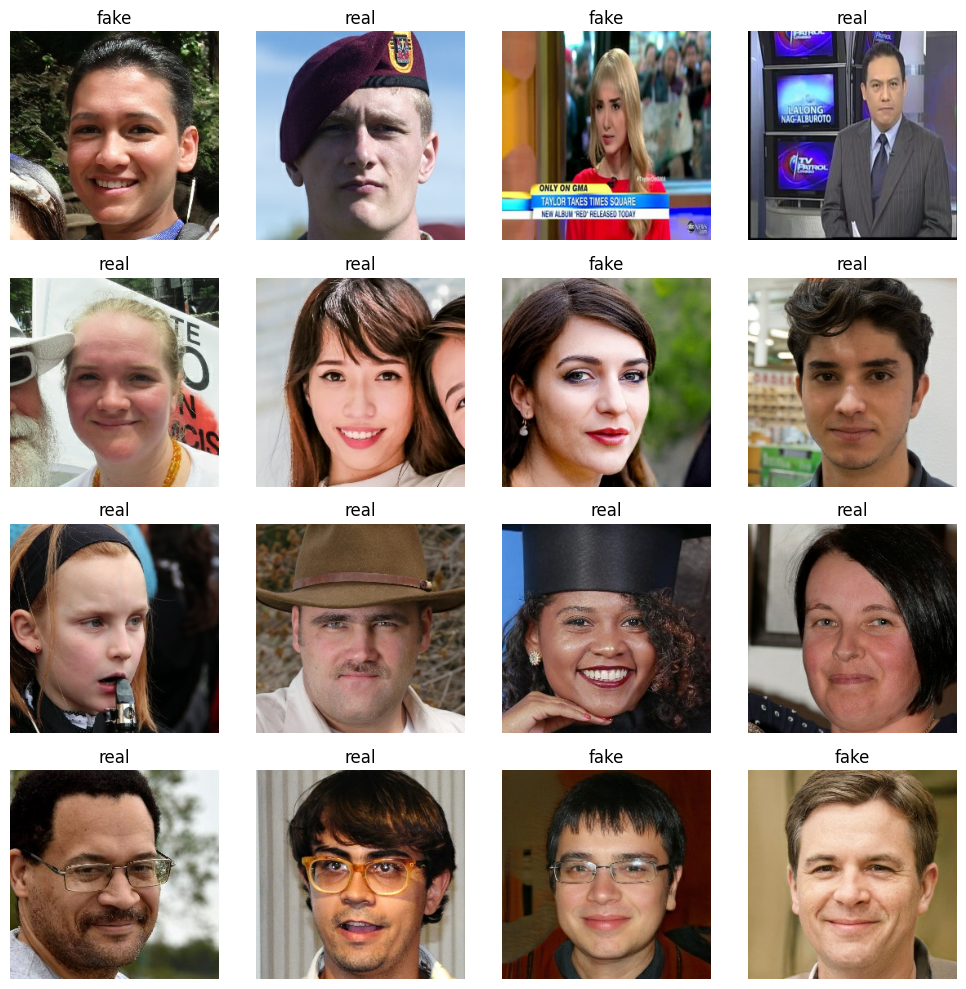

In [14]:
sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for index in range(min(16, len(sample_images))):
    plt.subplot(4, 4, index + 1)
    plt.imshow(tf.cast(sample_images[index], tf.uint8))
    label = int(sample_labels[index].numpy()[0])
    plt.title(CLASS_NAMES[label])
    plt.axis("off")

plt.tight_layout()
plt.savefig(RESULT_DIR / "train_sample_images.png", dpi=200)
plt.show()

## 6. 클래스 불균형 확인 및 Class Weight 설정

In [15]:
train_counts = count_images_by_class(TRAIN_DIR)
fake_count = train_counts["fake"]
real_count = train_counts["real"]
total_count = fake_count + real_count

imbalance_ratio = max(fake_count, real_count) / min(fake_count, real_count)
USE_CLASS_WEIGHT = imbalance_ratio >= 1.20

class_weight = {
    0: total_count / (2.0 * fake_count),
    1: total_count / (2.0 * real_count),
}

print("Train counts:", train_counts)
print("Imbalance ratio:", round(imbalance_ratio, 3))
print("Use class weight:", USE_CLASS_WEIGHT)
print("Class weight:", {key: round(value, 4) for key, value in class_weight.items()})

Train counts: {'fake': 123600, 'real': 123600}
Imbalance ratio: 1.0
Use class weight: False
Class weight: {0: 1.0, 1: 1.0}


## 7. EfficientNetV2S 모델 구축

### 학습 전략
1. **Head training**: ImageNet 사전학습 backbone을 동결하고 새 분류층만 학습
2. **Partial fine-tuning**: backbone 마지막 일부 레이어만 낮은 learning rate로 추가 학습

### 데이터 증강
데이터셋별 크롭·위치·대비 차이를 그대로 외우는 것을 줄이기 위해 약한 증강만 적용합니다.
- 좌우 반전
- 작은 회전
- 작은 확대/축소
- 작은 평행이동
- 약한 대비 변화

EfficientNetV2S 내부 전처리를 사용하므로 별도의 `/255.` 또는 `preprocess_input()`은 적용하지 않습니다.

In [16]:
tf.keras.backend.clear_session()

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.02),
        layers.RandomZoom(0.05),
        layers.RandomTranslation(height_factor=0.03, width_factor=0.03),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation",
)

def build_model():
    inputs = layers.Input(shape=(*IMAGE_SIZE, 3), name="input_image")
    x = data_augmentation(inputs)

    # include_preprocessing=True:
    # 입력은 [0, 255] 범위로 유지하며, 모델 내부 Rescaling을 사용합니다.
    base_model = tf.keras.applications.EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMAGE_SIZE, 3),
        include_preprocessing=True,
    )
    base_model.trainable = False

    feature_maps = base_model(x, training=False)

    classifier_head = tf.keras.Sequential(
        [
            layers.GlobalAveragePooling2D(name="global_average_pooling"),
            layers.Dropout(0.35, name="dropout"),
            layers.Dense(
                1,
                activation="sigmoid",
                dtype="float32",
                name="probability_real",
            ),
        ],
        name="classifier_head",
    )

    outputs = classifier_head(feature_maps)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="efficientnetv2s_fake_face")

    return model, base_model, classifier_head

def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision_real"),
            tf.keras.metrics.Recall(name="recall_real"),
        ],
    )

model, base_model, classifier_head = build_model()
compile_model(model, LEARNING_RATE_HEAD)

print("Model created.")
print("Backbone trainable:", base_model.trainable)
model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Model created.
Backbone trainable: False


Model: "efficientnetv2s_fake_face"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 8, 8, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_head (Sequential)    │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,332,641 (77.56 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

## 8. 콜백: 최적 가중치 저장, 조기 종료, 학습 재개 대비

In [17]:
def make_callbacks(phase_name: str, weight_path: Path):
    phase_backup_dir = BACKUP_DIR / phase_name
    phase_backup_dir.mkdir(parents=True, exist_ok=True)

    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(weight_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(
            str(RESULT_DIR / f"{phase_name}_training_log.csv")
        ),
        tf.keras.callbacks.BackupAndRestore(
            backup_dir=str(phase_backup_dir)
        ),
    ]

print("Head weights:", HEAD_WEIGHTS_PATH)
print("Fine-tuned weights:", FINE_WEIGHTS_PATH)

Head weights: outputs/efficientnetv2s_experiment_01/models/best_head.weights.h5
Fine-tuned weights: outputs/efficientnetv2s_experiment_01/models/best_finetuned.weights.h5


## 9. Phase 1: Head Training

In [18]:
history_head = None

if RUN_HEAD_TRAINING:
    print("=== Phase 1: classifier head training ===")
    print("Backbone frozen:", not base_model.trainable)

    history_head = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=HEAD_EPOCHS,
        callbacks=make_callbacks("head", HEAD_WEIGHTS_PATH),
        class_weight=class_weight if USE_CLASS_WEIGHT else None,
    )

    model.load_weights(HEAD_WEIGHTS_PATH)
    print("Loaded best head weights:", HEAD_WEIGHTS_PATH)
else:
    if HEAD_WEIGHTS_PATH.exists():
        model.load_weights(HEAD_WEIGHTS_PATH)
        print("RUN_HEAD_TRAINING=False, existing head weights loaded:", HEAD_WEIGHTS_PATH)
    else:
        raise FileNotFoundError(
            "RUN_HEAD_TRAINING=False인데 저장된 head weights가 없습니다. "
            "먼저 Phase 1을 실행하세요."
        )

=== Phase 1: classifier head training ===
Backbone frozen: True
Epoch 1/5


I0000 00:00:1779936029.355113   94560 cuda_dnn.cc:461] Loaded cuDNN version 92200


15450/15450 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7316 - auc: 0.8123 - loss: 0.5221 - precision_real: 0.7279 - recall_real: 0.7402
Epoch 1: val_auc improved from None to 0.86858, saving model to outputs/efficientnetv2s_experiment_01/models/best_head.weights.h5

Epoch 1: finished saving model to outputs/efficientnetv2s_experiment_01/models/best_head.weights.h5
15450/15450 ━━━━━━━━━━━━━━━━━━━━ 1165s 74ms/step - accuracy: 0.7443 - auc: 0.8274 - loss: 0.5059 - precision_real: 0.7406 - recall_real: 0.7519 - val_accuracy: 0.7335 - val_auc: 0.8686 - val_loss: 0.5056 - val_precision_real: 0.6712 - val_recall_real: 0.9156 - learning_rate: 0.0010
Epoch 2/5
15450/15450 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7506 - auc: 0.8346 - loss: 0.4979 - precision_real: 0.7471 - recall_real: 0.7580
Epoch 2: val_auc improved from 0.86858 to 0.87092, saving model to outputs/efficientnetv2s_experiment_01/models/best_head.weights.h5

Epoch 2: finished saving model to outputs/efficientnetv2s_ex

## 10. Phase 2: Partial Fine-tuning

Phase 1 결과가 정상적으로 나온 뒤 설정 셀에서 아래 값을 변경하고 실행하세요.

```python
RUN_HEAD_TRAINING = False
RUN_FINE_TUNING = True
```

- EfficientNetV2S 전체를 무작정 푸는 대신 마지막 `UNFREEZE_LAST_N`개 레이어만 학습합니다.
- BatchNormalization 레이어는 고정하여 fine-tuning 안정성을 높입니다.
- learning rate는 `1e-5`로 낮춥니다.

In [19]:
history_fine = None

if RUN_FINE_TUNING:
    if HEAD_WEIGHTS_PATH.exists():
        model.load_weights(HEAD_WEIGHTS_PATH)
        print("Fine-tuning 시작 전 best head weights 로드 완료.")
    else:
        raise FileNotFoundError("Fine-tuning 전에 HEAD_WEIGHTS_PATH가 필요합니다.")

    base_model.trainable = True

    for layer in base_model.layers[:-UNFREEZE_LAST_N]:
        layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    compile_model(model, LEARNING_RATE_FINE)

    trainable_backbone_layers = sum(layer.trainable for layer in base_model.layers)
    print("=== Phase 2: partial fine-tuning ===")
    print(f"Trainable backbone layers: {trainable_backbone_layers} / {len(base_model.layers)}")

    history_fine = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=FINETUNE_EPOCHS,
        callbacks=make_callbacks("finetune", FINE_WEIGHTS_PATH),
        class_weight=class_weight if USE_CLASS_WEIGHT else None,
    )

    model.load_weights(FINE_WEIGHTS_PATH)
    print("Loaded best fine-tuned weights:", FINE_WEIGHTS_PATH)
else:
    print("RUN_FINE_TUNING=False: Phase 1 모델로 평가합니다.")

RUN_FINE_TUNING=False: Phase 1 모델로 평가합니다.


## 11. 학습 곡선 저장 및 시각화

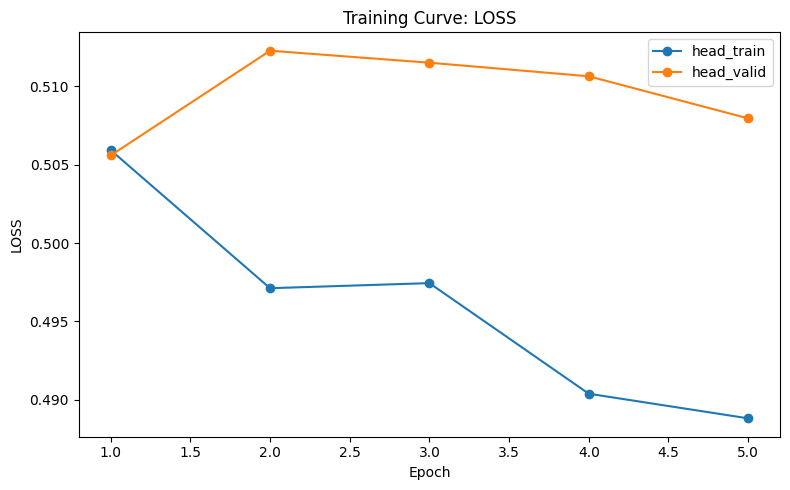

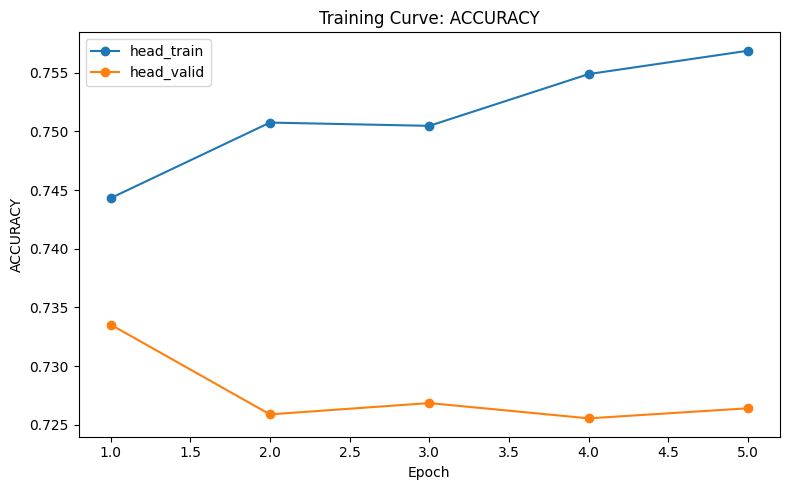

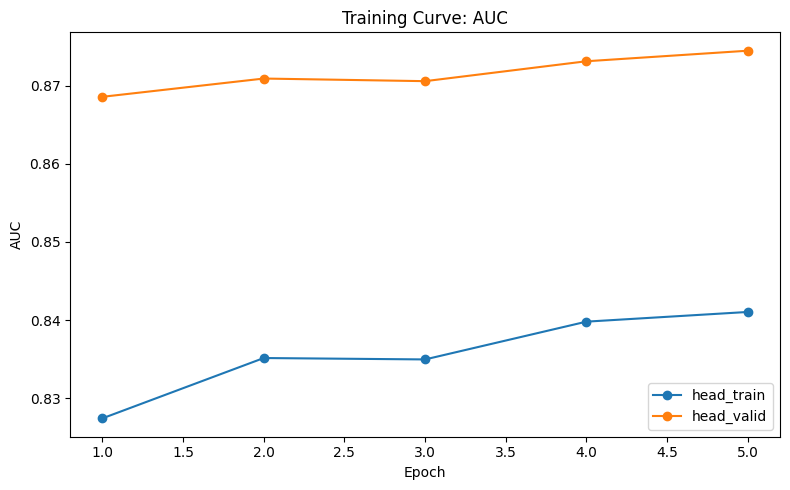

In [20]:
def history_to_dataframe(history, phase_name):
    if history is None:
        return None
    dataframe = pd.DataFrame(history.history)
    dataframe["epoch"] = np.arange(1, len(dataframe) + 1)
    dataframe["phase"] = phase_name
    return dataframe

history_frames = []
for history, phase_name in [(history_head, "head"), (history_fine, "finetune")]:
    dataframe = history_to_dataframe(history, phase_name)
    if dataframe is not None:
        history_frames.append(dataframe)

if history_frames:
    all_history = pd.concat(history_frames, ignore_index=True)
    all_history.to_csv(RESULT_DIR / "training_history.csv", index=False)

    for metric in ["loss", "accuracy", "auc"]:
        plt.figure(figsize=(8, 5))
        offset = 0
        for history, phase_name in [(history_head, "head"), (history_fine, "finetune")]:
            if history is None:
                continue
            epochs = np.arange(1 + offset, len(history.history[metric]) + 1 + offset)
            plt.plot(epochs, history.history[metric], marker="o", label=f"{phase_name}_train")
            plt.plot(epochs, history.history[f"val_{metric}"], marker="o", label=f"{phase_name}_valid")
            offset += len(history.history[metric])

        plt.title(f"Training Curve: {metric.upper()}")
        plt.xlabel("Epoch")
        plt.ylabel(metric.upper())
        plt.legend()
        plt.tight_layout()
        plt.savefig(RESULT_DIR / f"training_curve_{metric}.png", dpi=200)
        plt.show()
else:
    print("현재 세션에서 실행된 학습 history가 없습니다.")

## 12. 최종 가중치 선택 및 검증 데이터 기반 Threshold 선정

분류 threshold를 테스트셋에서 맞추면 데이터 누수가 됩니다.  
따라서 이 노트북은 **validation set에서 Macro F1가 가장 높은 threshold를 먼저 선정**하고, 그 threshold를 ID Test 및 모든 Source Test에 동일하게 적용합니다.


In [21]:
# 현재 실험에서 사용할 최종 가중치 선택
if RUN_FINE_TUNING and FINE_WEIGHTS_PATH.exists():
    model.load_weights(FINE_WEIGHTS_PATH)
    selected_weights = str(FINE_WEIGHTS_PATH)
elif HEAD_WEIGHTS_PATH.exists():
    model.load_weights(HEAD_WEIGHTS_PATH)
    selected_weights = str(HEAD_WEIGHTS_PATH)
else:
    raise FileNotFoundError("평가할 가중치 파일이 없습니다. 먼저 학습을 실행하세요.")

print("Selected weights:", selected_weights)

def collect_labels(dataset):
    return np.concatenate([labels.numpy().reshape(-1) for _, labels in dataset]).astype(int)

def predict_prob_real(model, dataset):
    return model.predict(dataset, verbose=1).reshape(-1)

valid_true = collect_labels(valid_ds)
valid_prob_real = predict_prob_real(model, valid_ds)

def choose_threshold_by_macro_f1(y_true, y_prob_real):
    thresholds = np.arange(0.05, 0.951, 0.01)
    scores = []
    for threshold in thresholds:
        predictions = (y_prob_real >= threshold).astype(int)
        score = f1_score(y_true, predictions, average="macro", zero_division=0)
        scores.append(score)
    best_index = int(np.argmax(scores))
    return float(thresholds[best_index]), float(scores[best_index])

if OPTIMIZE_THRESHOLD_ON_VALID:
    DECISION_THRESHOLD, valid_best_macro_f1 = choose_threshold_by_macro_f1(
        valid_true, valid_prob_real
    )
else:
    DECISION_THRESHOLD = 0.5
    valid_predictions = (valid_prob_real >= DECISION_THRESHOLD).astype(int)
    valid_best_macro_f1 = f1_score(
        valid_true, valid_predictions, average="macro", zero_division=0
    )

print("Decision threshold selected on VALID set:", round(DECISION_THRESHOLD, 4))
print("Validation Macro F1 at threshold:", round(valid_best_macro_f1, 4))

Selected weights: outputs/efficientnetv2s_experiment_01/models/best_head.weights.h5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 105s 43ms/step
Decision threshold selected on VALID set: 0.71
Validation Macro F1 at threshold: 0.7983


## 13. ID Test / Source Test 평가 및 결과 저장

`test_by_source`에 존재하는 모든 생성 소스별 결과를 저장합니다.  
그중 `OOD_SOURCE_NAMES`에 등록한 소스만 결과표에서 `ood`로 표시됩니다.


2400/2400 ━━━━━━━━━━━━━━━━━━━━ 103s 43ms/step


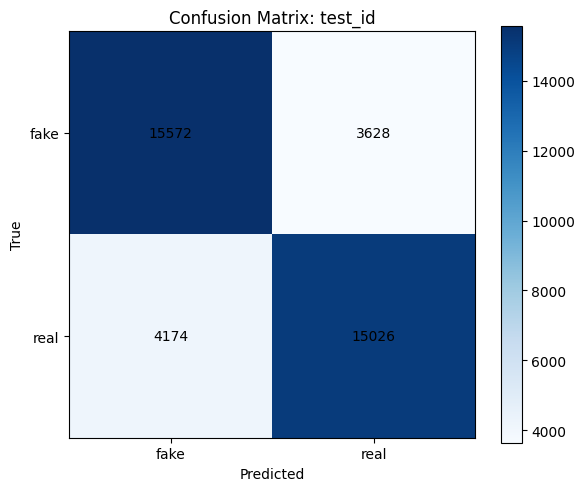

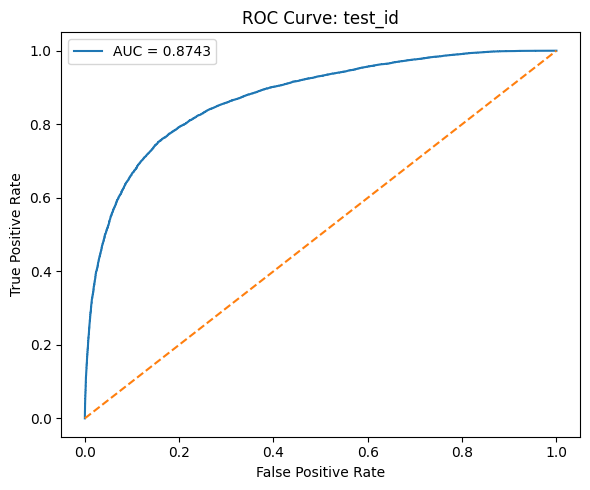

575/575 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step


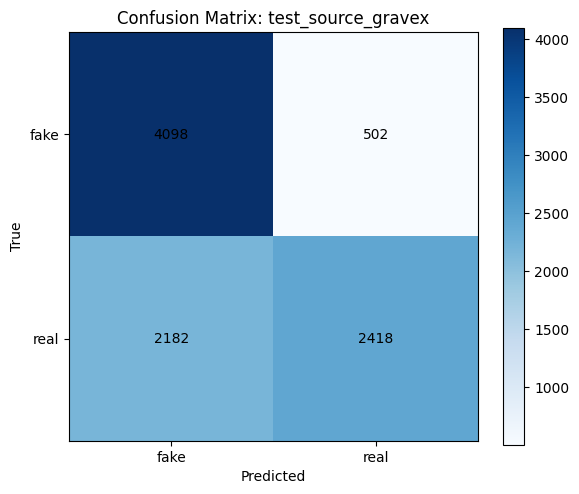

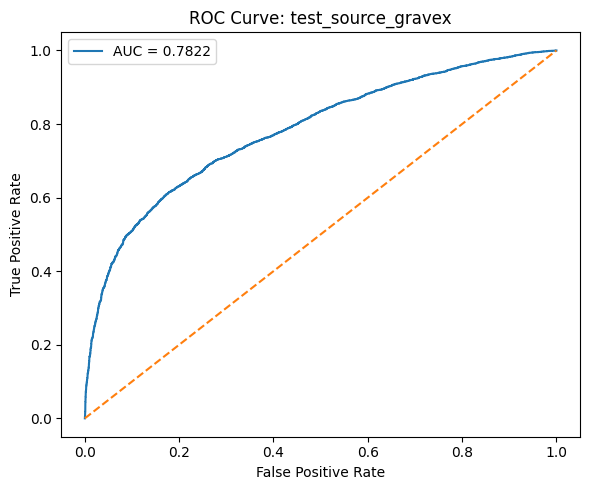

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step


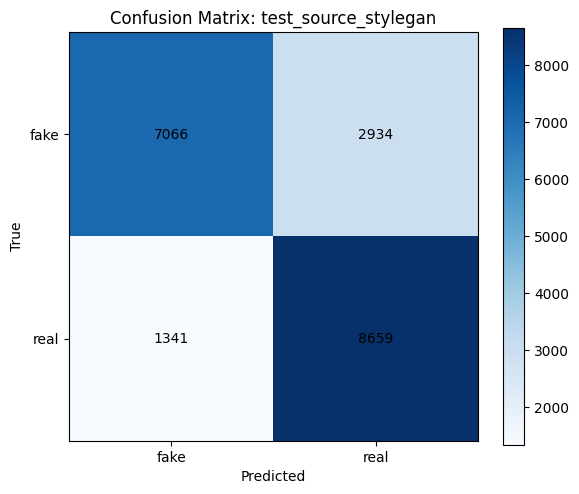

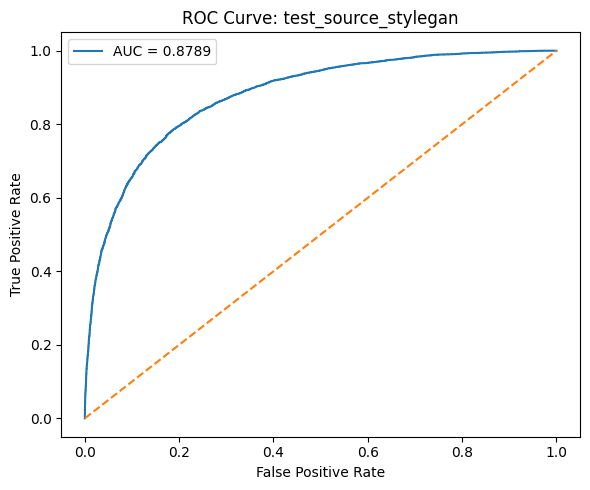

575/575 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step


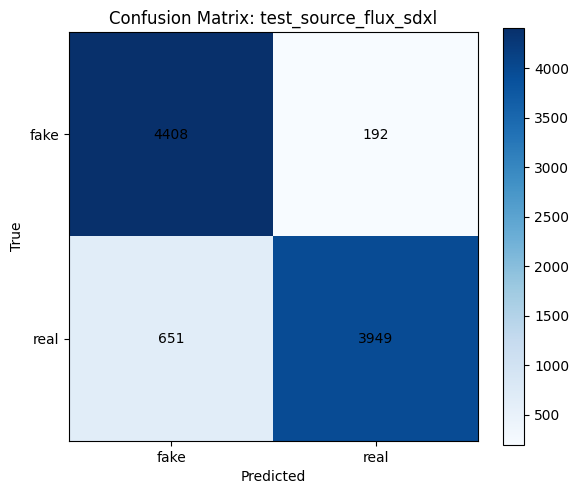

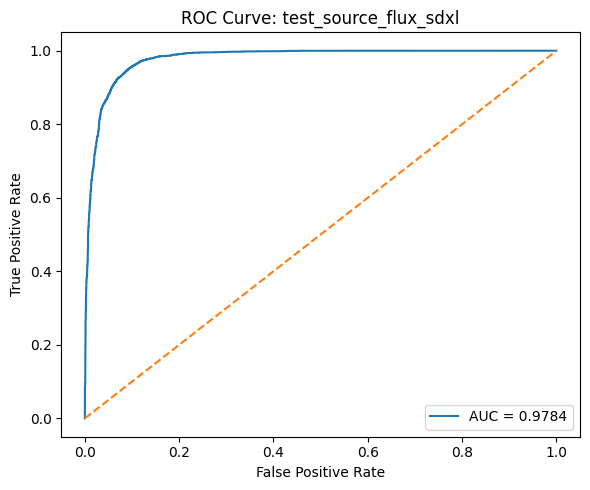

,dataset,evaluation_type,source_name,is_ood,n_images,threshold,accuracy,roc_auc_real_positive,macro_f1,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1
0,test_id,id,combined_id_test,False,38400,0.71,0.796823,0.874257,0.796782,0.788615,0.811042,0.799671,0.805511,0.782604,0.793892
1,test_source_gravex,source_seen_or_mixed,gravex,False,9200,0.71,0.708261,0.782183,0.698197,0.652548,0.890870,0.753309,0.828082,0.525652,0.643085
2,test_source_stylegan,source_seen_or_mixed,stylegan,False,20000,0.71,0.786250,0.878912,0.784885,0.840490,0.706600,0.767751,0.746916,0.865900,0.802019
3,test_source_flux_sdxl,source_seen_or_mixed,flux_sdxl,False,9200,0.71,0.908370,0.978416,0.908141,0.871318,0.958261,0.912724,0.953634,0.858478,0.903558


In [22]:
def evaluate_dataset(model, dataset, dataset_name, threshold, evaluation_type, source_name=None):
    y_true = collect_labels(dataset)
    y_prob_real = predict_prob_real(model, dataset)
    y_pred = (y_prob_real >= threshold).astype(int)

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    auc = roc_auc_score(y_true, y_prob_real) if len(np.unique(y_true)) == 2 else np.nan

    summary = {
        "dataset": dataset_name,
        "evaluation_type": evaluation_type,
        "source_name": source_name if source_name is not None else "combined_id_test",
        "is_ood": evaluation_type == "ood",
        "n_images": len(y_true),
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc_real_positive": auc,
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "fake_precision": report["fake"]["precision"],
        "fake_recall": report["fake"]["recall"],
        "fake_f1": report["fake"]["f1-score"],
        "real_precision": report["real"]["precision"],
        "real_recall": report["real"]["recall"],
        "real_f1": report["real"]["f1-score"],
    }

    report_df = pd.DataFrame(report).T
    report_df.to_csv(RESULT_DIR / f"{dataset_name}_classification_report.csv")

    predictions_df = pd.DataFrame({
        "true_label": y_true,
        "true_class": [CLASS_NAMES[label] for label in y_true],
        "prob_real": y_prob_real,
        "prob_fake": 1.0 - y_prob_real,
        "pred_label": y_pred,
        "pred_class": [CLASS_NAMES[label] for label in y_pred],
    })
    predictions_df.to_csv(RESULT_DIR / f"{dataset_name}_predictions.csv", index=False)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks([0, 1], CLASS_NAMES)
    plt.yticks([0, 1], CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix: {dataset_name}")

    for row in range(2):
        for col in range(2):
            plt.text(col, row, cm[row, col], ha="center", va="center")

    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"{dataset_name}_confusion_matrix.png", dpi=200)
    plt.show()

    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob_real)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve: {dataset_name}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(RESULT_DIR / f"{dataset_name}_roc_curve.png", dpi=200)
        plt.show()

    return summary

evaluation_summaries = [
    evaluate_dataset(
        model, test_id_ds, "test_id", DECISION_THRESHOLD,
        evaluation_type="id", source_name=None
    )
]

for source_name, source_dataset in source_test_datasets.items():
    evaluation_type = "ood" if source_name in OOD_SOURCE_NAMES else "source_seen_or_mixed"
    evaluation_summaries.append(
        evaluate_dataset(
            model,
            source_dataset,
            f"test_source_{source_name}",
            DECISION_THRESHOLD,
            evaluation_type=evaluation_type,
            source_name=source_name,
        )
    )

evaluation_summary_df = pd.DataFrame(evaluation_summaries)
evaluation_summary_df.to_csv(RESULT_DIR / "evaluation_summary.csv", index=False)
display(evaluation_summary_df)


## 14. 최종 모델 및 추론 설정 저장

In [23]:
inference_config = {
    "model_name": "EfficientNetV2S",
    "image_size": list(IMAGE_SIZE),
    "class_names": CLASS_NAMES,
    "label_mapping": {"fake": 0, "real": 1},
    "output_interpretation": "model output is probability of real",
    "decision_threshold_real": DECISION_THRESHOLD,
    "selected_weights": selected_weights,
    "run_name": RUN_NAME,
}

with open(INFERENCE_CONFIG_PATH, "w", encoding="utf-8") as file:
    json.dump(inference_config, file, ensure_ascii=False, indent=2)

model.save(FINAL_MODEL_PATH)

print("Saved final model:", FINAL_MODEL_PATH)
print("Saved inference config:", INFERENCE_CONFIG_PATH)

# 저장된 모델이 실제로 다시 열리는지 확인
loaded_model = tf.keras.models.load_model(FINAL_MODEL_PATH)
test_batch, _ = next(iter(test_id_ds))
reload_predictions = loaded_model.predict(test_batch[:2], verbose=0).reshape(-1)

print("Model reload test passed.")
print("Reload prediction sample (P(real)):", reload_predictions)

Saved final model: outputs/efficientnetv2s_experiment_01/models/efficientnetv2s_fake_face_final.keras
Saved inference config: outputs/efficientnetv2s_experiment_01/models/inference_config.json
Model reload test passed.
Reload prediction sample (P(real)): [0.11084391 0.0537513 ]


## 15. 단일 이미지 예측 함수

In [ ]:
def find_first_image(directory: Path):
    files = list_image_files(directory)
    if not files:
        raise FileNotFoundError(f"이미지가 없습니다: {directory}")
    return files[0]

def predict_single_image(model, image_path: Path, threshold: float):
    image = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    image_array = tf.keras.utils.img_to_array(image)
    image_batch = np.expand_dims(image_array, axis=0)

    # EfficientNetV2S 모델 내부 preprocessing을 사용하므로 /255 하지 않습니다.
    probability_real = float(model.predict(image_batch, verbose=0)[0][0])
    probability_fake = 1.0 - probability_real
    predicted_class = "real" if probability_real >= threshold else "fake"

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Pred: {predicted_class}\n"
        f"Fake {probability_fake * 100:.2f}% | Real {probability_real * 100:.2f}%"
    )
    plt.tight_layout()
    plt.show()

    return {
        "image_path": str(image_path),
        "prediction": predicted_class,
        "probability_fake": probability_fake,
        "probability_real": probability_real,
        "threshold_real": threshold,
    }

fake_example_path = find_first_image(TEST_DIR / "fake")
real_example_path = find_first_image(TEST_DIR / "real")

print(predict_single_image(model, fake_example_path, DECISION_THRESHOLD))
print(predict_single_image(model, real_example_path, DECISION_THRESHOLD))

## 16. Grad-CAM 시각화

EfficientNetV2S의 마지막 convolution layer인 `top_conv`를 이용합니다.  
예측이 fake이면 `P(fake) = 1 - P(real)`에 기여한 영역을, real이면 `P(real)`에 기여한 영역을 시각화합니다.

In [ ]:
import matplotlib.cm as cm
from IPython.display import display, Image as IPythonImage

LAST_CONV_LAYER_NAME = "top_conv"

def build_gradcam_feature_model(base_model):
    if not any(layer.name == LAST_CONV_LAYER_NAME for layer in base_model.layers):
        conv_candidates = [
            layer.name for layer in base_model.layers
            if isinstance(layer, layers.Conv2D)
        ]
        raise ValueError(
            f"'{LAST_CONV_LAYER_NAME}' 레이어를 찾지 못했습니다. "
            f"마지막 Conv2D 후보: {conv_candidates[-5:]}"
        )

    return tf.keras.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(LAST_CONV_LAYER_NAME).output,
            base_model.output,
        ],
        name="efficientnetv2s_gradcam_features",
    )

gradcam_feature_model = build_gradcam_feature_model(base_model)

def make_gradcam_heatmap(image_batch, threshold):
    with tf.GradientTape() as tape:
        augmented_images = data_augmentation(image_batch, training=False)
        conv_outputs, backbone_outputs = gradcam_feature_model(
            augmented_images, training=False
        )
        prediction_real = classifier_head(backbone_outputs, training=False)[:, 0]
        predicted_real = prediction_real[0] >= threshold
        target_score = prediction_real if predicted_real else (1.0 - prediction_real)

    gradients = tape.gradient(target_score, conv_outputs)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_gradients, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())

    return heatmap.numpy(), float(prediction_real[0])

def save_gradcam_overlay(image_path: Path, heatmap, output_path: Path, alpha=0.4):
    original_image = tf.keras.utils.load_img(image_path)
    original_array = tf.keras.utils.img_to_array(original_image)

    heatmap_uint8 = np.uint8(255 * heatmap)
    colormap = cm.get_cmap("jet")
    colored_heatmap = colormap(np.arange(256))[:, :3][heatmap_uint8]

    colored_heatmap = tf.keras.utils.array_to_img(colored_heatmap)
    colored_heatmap = colored_heatmap.resize(
        (original_array.shape[1], original_array.shape[0])
    )
    colored_heatmap = tf.keras.utils.img_to_array(colored_heatmap)

    overlay = tf.keras.utils.array_to_img(
        colored_heatmap * alpha + original_array
    )
    overlay.save(output_path)
    display(IPythonImage(filename=str(output_path)))

def run_gradcam(image_path: Path, output_filename: str):
    image = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    image_array = tf.keras.utils.img_to_array(image)
    image_batch = np.expand_dims(image_array, axis=0)

    heatmap, probability_real = make_gradcam_heatmap(
        image_batch, DECISION_THRESHOLD
    )
    probability_fake = 1.0 - probability_real
    predicted_class = "real" if probability_real >= DECISION_THRESHOLD else "fake"

    output_path = GRADCAM_DIR / output_filename
    print("Image:", image_path)
    print(
        f"Pred: {predicted_class} | "
        f"Fake {probability_fake * 100:.2f}% | Real {probability_real * 100:.2f}%"
    )
    save_gradcam_overlay(image_path, heatmap, output_path)

run_gradcam(fake_example_path, "gradcam_fake_example.jpg")
run_gradcam(real_example_path, "gradcam_real_example.jpg")

## 17. Streamlit 시연 앱 코드 내보내기

학습과 모델 저장이 완료된 뒤 아래 셀을 실행하면 `outputs/<RUN_NAME>/app/streamlit_app.py`가 생성됩니다.

터미널 실행 예시:

```bash
streamlit run outputs/efficientnetv2s_experiment_01/app/streamlit_app.py
```

In [ ]:
streamlit_app_code = f"""
from pathlib import Path
import json
import numpy as np
import streamlit as st
import tensorflow as tf
from PIL import Image

APP_DIR = Path(__file__).resolve().parent
MODEL_PATH = APP_DIR.parent / "models" / "efficientnetv2s_fake_face_final.keras"
CONFIG_PATH = APP_DIR.parent / "models" / "inference_config.json"

st.set_page_config(page_title="AI Face Detector", page_icon="🔍", layout="centered")

@st.cache_resource
def load_resources():
    model = tf.keras.models.load_model(MODEL_PATH)
    with open(CONFIG_PATH, "r", encoding="utf-8") as file:
        config = json.load(file)
    return model, config

model, config = load_resources()
image_size = tuple(config["image_size"])
threshold = float(config["decision_threshold_real"])

st.title("AI-Generated Face Detection")
st.caption("EfficientNetV2S 기반 AI 생성 얼굴 탐지 시연")

uploaded_file = st.file_uploader(
    "얼굴 이미지를 업로드하세요.",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded image", use_container_width=True)

    resized = image.resize(image_size)
    image_array = np.asarray(resized, dtype=np.float32)
    image_batch = np.expand_dims(image_array, axis=0)

    # 모델 내부에 EfficientNetV2S preprocessing이 포함되어 있으므로 /255 하지 않습니다.
    probability_real = float(model.predict(image_batch, verbose=0)[0][0])
    probability_fake = 1.0 - probability_real
    prediction = "REAL" if probability_real >= threshold else "AI / FAKE"

    st.subheader(f"Prediction: {{prediction}}")
    st.metric("AI / FAKE probability", f"{{probability_fake * 100:.2f}}%")
    st.metric("REAL probability", f"{{probability_real * 100:.2f}}%")
    st.caption(f"Decision threshold for REAL: {{threshold:.3f}}")

    st.progress(int(round(probability_fake * 100)), text="AI / FAKE probability")

st.divider()
st.caption("This model provides a probability-based estimate and may fail on unseen generation methods or edited images.")
"""

app_file_path = APP_DIR / "streamlit_app.py"
with open(app_file_path, "w", encoding="utf-8") as file:
    file.write(streamlit_app_code)

requirements_text = """tensorflow
numpy
pillow
streamlit
"""

with open(APP_DIR / "requirements.txt", "w", encoding="utf-8") as file:
    file.write(requirements_text)

print("Streamlit app created:", app_file_path)
print("Requirements file created:", APP_DIR / "requirements.txt")

## 18. 실행 순서 요약

### 1단계: 설치 및 데이터 준비
- 설정 셀의 `DATA_DIR`을 본인 데이터 위치로 변경
- `train / valid / test` 폴더 안에 각각 `fake / real` 폴더 준비
- `test_by_source/<source>/fake`, `test_by_source/<source>/real` 폴더 준비
- 설정 셀의 `OOD_SOURCE_NAMES`에는 **train에 들어가지 않은 소스만** 작성
- `prepare_dataset.py`를 사용할 경우, 해당 스크립트도 `data/test_by_source/`를 생성하도록 통일
- 가능하면 최종 학습 전 손상 파일 검사와 완전 중복 검사를 한 번 실행

### 2단계: 최초 동작 확인
설정값:

```python
BATCH_SIZE = 16
HEAD_EPOCHS = 3
RUN_HEAD_TRAINING = True
RUN_FINE_TUNING = False
```

처음에는 작은 데이터 또는 전체 데이터의 일부로 오류 없이 끝까지 실행되는지 확인합니다.

### 3단계: 본 학습
문제 없이 실행되면:

```python
HEAD_EPOCHS = 5
RUN_HEAD_TRAINING = True
RUN_FINE_TUNING = False
```

로 head training 결과를 먼저 저장합니다.

### 4단계: Fine-tuning
Phase 1 결과가 정상이라면:

```python
RUN_HEAD_TRAINING = False
RUN_FINE_TUNING = True
FINETUNE_EPOCHS = 5
```

로 마지막 일부 레이어만 추가 학습합니다.

### 5단계: 결과 확인
`outputs/<RUN_NAME>/results/`에서 다음 결과를 확인합니다.

```text
dataset_distribution.csv
training_history.csv
evaluation_summary.csv
test_id_confusion_matrix.png
test_id_roc_curve.png
test_source_gravex_confusion_matrix.png
test_source_stylegan_confusion_matrix.png
test_source_flux_sdxl_confusion_matrix.png
```

`evaluation_summary.csv`의 `evaluation_type` 열에서:
- `id`: 통합 독립 테스트 결과
- `source_seen_or_mixed`: source별 결과이지만 자동으로 OOD로 해석하지 않는 결과
- `ood`: 학습에 포함하지 않은 source에 대한 일반화 평가 결과

### 6단계: 시연 앱 실행
최종 모델 저장과 앱 코드 내보내기 셀까지 실행한 뒤:

```bash
streamlit run outputs/efficientnetv2s_experiment_01/app/streamlit_app.py
```

### 메모리 부족 오류가 나면
설정 셀에서 아래처럼 낮추고 커널을 재시작한 뒤 다시 실행하세요.

```python
BATCH_SIZE = 8
```
